In [ ]:
# Case Study 1
# Step !
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
# Step 2 a
data=pd.read_csv("RCaseStudy1_Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'RCaseStudy1_Dataset.csv'

In [ ]:
#Step 2 b
#np.random.seed(42) #Used in NumPy to make random number generation reproducible.
# 42 is a number popularized by The Hitchhiker’s Guide to the Galaxy as “the answer to life, the universe, and everything”
#If you run your code today and again tomorrow, you should get the same output.

#area=np.random.uniform(500,3000,100)

#price = 50000 + (area * 150) + np.random.normal(0, 20000, 100)

#data =pd.DataFrame({'Area':area,'Price':price})

In [ ]:
#Step 3
plt.scatter(data["Area"], data["Price"])
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("House Price Dataset")
plt.show()

In [ ]:
# Step 4
X= data[['Area']]
y= data['Price']

linear_model=LinearRegression();
linear_model.fit(X,y);

y_pred_linear= linear_model.predict(X);

In [ ]:
#Step 5
plt.scatter(X, y)
plt.plot(X, y_pred_linear, color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression Fit")
plt.show()

In [ ]:
# Step 6
mse_linear=mean_squared_error(y,y_pred_linear);
print("Linear Regression MSE:", mse_linear)

root_mean_squared_error_linear=np.sqrt(mse_linear);
print("Linear Regression RMSE:", root_mean_squared_error_linear)

In [ ]:
# Step 7
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred_poly = poly_model.predict(X_poly)

In [ ]:
# Step 8
sorted_zip = sorted(zip(X["Area"], y_pred_poly))
X_sorted, y_poly_sorted = zip(*sorted_zip)

# It first pairs each house’s area with its predicted price using zip().
# Then it sorts those pairs by area (smallest to largest).
# This helps you plot a smooth prediction line instead of a messy zigzag graph.

plt.scatter(X, y)
plt.plot(X_sorted, y_poly_sorted, color='green')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Polynomial Regression Fit")
plt.show()

NameError: name 'X' is not defined

In [ ]:
#Step 9
mse_poly = mean_squared_error(y, y_pred_poly)
print("Polynomial Regression MSE:", mse_poly)
root_mean_squared_error_linear=np.sqrt(mse_poly);
print("Polynomial Regression RMSE:", root_mean_squared_error_linear)

In [ ]:
#Case Study 2
#Step 1
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
#Step 2
data=pd.read_csv("RCaseStudy2_Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'RCaseStudy2_Dataset.csv'

In [ ]:
#Step 3
X = data[["Income", "CreditScore", "DebtRatio", "EmploymentYears", "LoanAmount"]]
y = data["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
#Step 4 - To Check it
ay=data.head(5);
print(ay)

In [ ]:
#STEP 4 – Train Logistic Model
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
# Step 5 Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

In [ ]:
#Step 6 Print Classification Report
print(classification_report(y_test, y_pred))

In [ ]:
#Step 7- Save a model
# Save model & scaler
import joblib
joblib.dump(model, "credit_model.pkl")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Then train your model with X_train_scaled
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

In [ ]:
from google.colab import files
files.download("credit_model.pkl")
files.download("scaler.pkl")

In [ ]:
#Case Study 3
#Step 1 Import Libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
data=pd.read_csv("CaseStudy3_Dataset.csv")

In [ ]:
print(data.head())

In [ ]:
# Define Sepsis Risk Rule
data["Sepsis"] = (
    (data["HeartRate"] > 100) &
    (data["Temperature"] > 100) &
    (data["WBC"] > 12000)
).astype(int)


NameError: name 'data' is not defined

In [ ]:
X = data.drop("Sepsis", axis=1)
y = data["Sepsis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

print("Sample Probabilities:")
print(y_prob[:10])

In [ ]:
#Case Study 4
#Stock Trend Classification
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
# The ValueError (Found array with 0 sample(s)) occurs because the DataFrame
# 'stock' becomes empty in subsequent cells due to aggressive .dropna() calls.
# This import cell cannot directly fix that data processing issue.

In [ ]:
#stock = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
#stock = stock.dropna()
#stock.head()

In [ ]:
stock_symbol = "AAPL"  # Define the stock symbol here
stock = yf.download(
    stock_symbol,
    start="2015-01-01",
    end="2024-01-01",
    progress=False
)

if stock.empty:
    raise ValueError("Stock data download failed. Check internet or ticker symbol.")

In [ ]:
stock=pd.read_csv("stock_backup.csv")

In [ ]:
stock.head()

In [ ]:
from google.colab import sheets
# Flatten the MultiIndex columns to single-level column names
# The previous line 'stock.columns = stock.columns.get_level_values(1)' caused an IndexError because the columns were already single-level.
# The 'stock.head()' output also indicates that column names were not the standard ones (e.g., 'Close').
# We will explicitly rename the columns to the expected financial metrics.
stock.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
sheet = sheets.InteractiveSheet(df=stock)

In [ ]:
stock["Return"] = stock["Close"].pct_change()
stock["MA_5"] = stock["Close"].rolling(5).mean()
stock["MA_10"] = stock["Close"].rolling(10).mean()
stock["MA_20"] = stock["Close"].rolling(20).mean()
stock["Volatility"] = stock["Return"].rolling(5).std()


In [ ]:
stock["Target"] = (stock["Close"].shift(-1) > stock["Close"]).astype(int)
stock=stock.dropna();

In [ ]:
features = ["Return", "MA_5", "MA_10", "MA_20", "Volatility"]

X = stock[features]
y = stock["Target"]

In [ ]:
split = int(len(stock) * 0.8)

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [ ]:
print("X shape:", X.shape)
print("Split index:", split)
print("Train shape:", X_train.shape)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
baseline = y_test.value_counts(normalize=True).max()
print("Baseline Accuracy:", baseline)

In [ ]:
stock.to_csv("stock_backup.csv")

In [ ]:
#Case Study 5
#Step 1
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


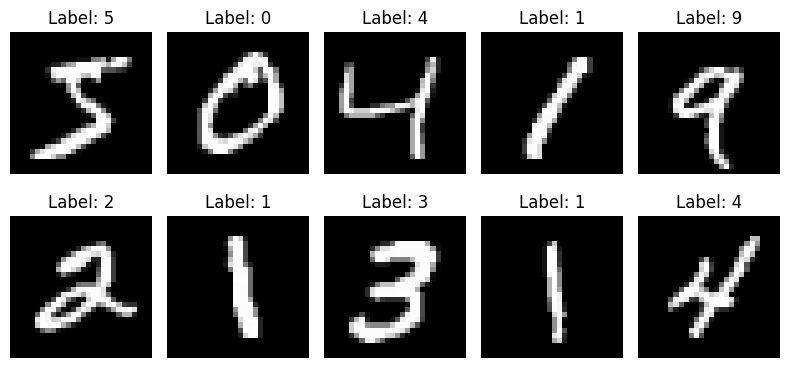

In [ ]:
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9924 - loss: 0.0252 - val_accuracy: 0.9808 - val_loss: 0.0741
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9972 - loss: 0.0124 - val_accuracy: 0.9803 - val_loss: 0.0756
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9983 - loss: 0.0089 - val_accuracy: 0.9815 - val_loss: 0.0739
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9984 - loss: 0.0080 - val_accuracy: 0.9785 - val_loss: 0.0848
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9989 - loss: 0.0066 - val_accuracy: 0.9815 - val_loss: 0.0804
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9989 - loss: 0.0063 - val_accuracy: 0.9810 - val_loss: 0.0823
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9990 - loss: 0.0055 - val_accuracy: 0.9792 - val_loss: 0.0868
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9990 - loss: 0.0050 - val_accuracy: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.1115
Test Accuracy: 0.9782000184059143


In [ ]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


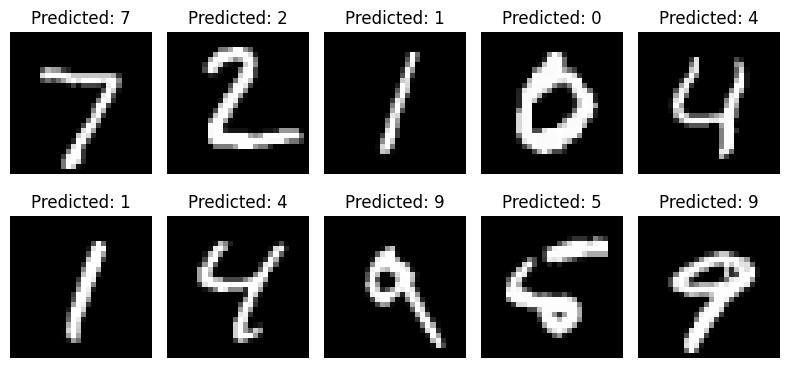

In [ ]:
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
True Label: 7
Predicted Label: 7
Prediction Probabilities: [[1.0537112e-15 6.4952076e-12 4.5073687e-09 1.6995010e-07 1.5166508e-10
  3.8820191e-19 3.5708055e-18 9.9999988e-01 1.1009923e-12 3.9317726e-16]]


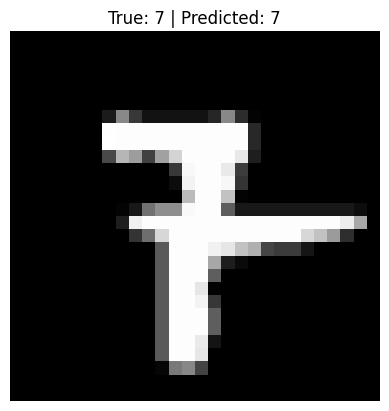

In [ ]:
# -----------------------------------------
# Predict a Specific Image
# -----------------------------------------

index = 97  # Change this number to test different images

image = X_test[index]
true_label = y_test[index]

# Model expects batch input, so reshape
image_reshaped = np.expand_dims(image, axis=0)

prediction = model.predict(image_reshaped)
predicted_digit = np.argmax(prediction)

print("True Label:", true_label)
print("Predicted Label:", predicted_digit)
print("Prediction Probabilities:", prediction)

# Show image
plt.imshow(image, cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_digit}")
plt.axis("off")
plt.show()

Enter test image index (0–9999): 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
True Label: 4
Predicted Label: 4


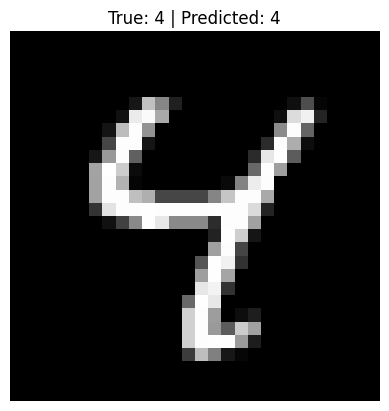

In [ ]:
index = int(input("Enter test image index (0–9999): "))

image = X_test[index]
true_label = y_test[index]

image_reshaped = np.expand_dims(image, axis=0)
prediction = model.predict(image_reshaped)
predicted_digit = np.argmax(prediction)

print("True Label:", true_label)
print("Predicted Label:", predicted_digit)

plt.imshow(image, cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_digit}")
plt.axis("off")
plt.show()

In [ ]:
model.save("mnist_model.h5")

In [ ]:
#Case Study 6
#Semantic Similarity using Neural Networks (Mini Plagiarism Checker)
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
text1 = "Machine learning is used to predict house prices."
text2 = "AI models can estimate property values."

In [ ]:
embedding1 = model.encode([text1])
embedding2 = model.encode([text2])

In [ ]:
similarity_score = cosine_similarity(embedding1, embedding2)[0][0]
print("Similarity Score:", round(similarity_score, 3))

Similarity Score: 0.493


In [ ]:
text3 = "The football match was exciting."

embedding3 = model.encode([text3])
similarity_score2 = cosine_similarity(embedding1, embedding3)[0][0]

print("Similarity with unrelated sentence:", round(similarity_score2, 3))

Similarity with unrelated sentence: -0.021


In [ ]:
text1 = input("Enter First Text: ")
text2 = input("Enter Second Text: ")

embedding1 = model.encode([text1])
embedding2 = model.encode([text2])

similarity_score = cosine_similarity(embedding1, embedding2)[0][0]

print("\nSimilarity Score:", round(similarity_score, 3))

if similarity_score > 0.75:
    print("⚠️ High Similarity – Possible Plagiarism")
elif similarity_score > 0.5:
    print("⚠️ Moderate Similarity")
else:
    print("✅ Low Similarity – Likely Different Content")

Enter First Text: machine
Enter Second Text: learning

Similarity Score: 0.386
✅ Low Similarity – Likely Different Content


In [ ]:
#Case Study 7
!pip install sentence-transformers scikit-learn numpy

In [ ]:
documents = [
    "Machine learning is a subset of artificial intelligence that focuses on data-driven prediction.",
    "Neural networks are inspired by biological neurons and are used in deep learning.",
    "Retrieval-Augmented Generation combines document retrieval with language generation.",
    "Embeddings convert text into high-dimensional numerical vectors.",
    "Cosine similarity measures similarity between two vectors."
]

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(documents)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
query = "What is RAG?"
query_embedding = model.encode([query])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

similarities = cosine_similarity(query_embedding, doc_embeddings)

top_index = np.argmax(similarities)
retrieved_doc = documents[top_index]

print("Most Relevant Document:")
print(retrieved_doc)

Most Relevant Document:
Retrieval-Augmented Generation combines document retrieval with language generation.


In [ ]:
response = f"Based on retrieved knowledge: {retrieved_doc}"

print("\nChatbot Response:")
print(response)


Chatbot Response:
Based on retrieved knowledge: Retrieval-Augmented Generation combines document retrieval with language generation.


In [ ]:
def generate_response(query, retrieved_text):
    return f"Question: {query}\n\nAnswer (Grounded): {retrieved_text}"

print(generate_response(query, retrieved_doc))

Question: What is RAG?

Answer (Grounded): Retrieval-Augmented Generation combines document retrieval with language generation.


In [ ]:
while True:
    query = input("\nAsk a question (type 'exit' to stop): ")
    if query.lower() == 'exit':
        break

    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, doc_embeddings)
    top_index = np.argmax(similarities)
    retrieved_doc = documents[top_index]

    print("\nAnswer:", retrieved_doc)


Ask a question (type 'exit' to stop): hu

Answer: Retrieval-Augmented Generation combines document retrieval with language generation.

Ask a question (type 'exit' to stop): hi

Answer: Machine learning is a subset of artificial intelligence that focuses on data-driven prediction.

Ask a question (type 'exit' to stop): exit
